In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn

In [6]:
col_names=['pregnant','glucose','bp','skin','insulin','bmi','pedigree','age','label']
data=pd.read_csv("diabetes.csv",header=None,names=col_names)
print(data.shape)
data.head()

(768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
#check if there is any null value in the dataset
data.isnull().sum()

pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

In [8]:
#making independent and dependent variables
feature_cols=['pregnant','insulin','bmi','age','glucose','bp','pedigree']
X=data[feature_cols]
y=data.label

In [9]:
#spitting dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(614, 7)

(154, 7)

(614,)

(154,)

In [10]:
#fittiing the model with training data
model = LogisticRegression(solver='lbfgs', max_iter=1000)
y_pred=model.fit(X_train, y_train).predict(X_test)

In [11]:
#Evvaluatiion metrics
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix:', confusion_matrix)
Accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy:', Accuracy)
print('Accuracy in percentage:', int(Accuracy*100),'%')


Confusion Matrix: [[88 12]
 [19 35]]
Accuracy: 0.7987012987012987
Accuracy in percentage: 79 %


<Axes: xlabel='Predicted', ylabel='Actual'>

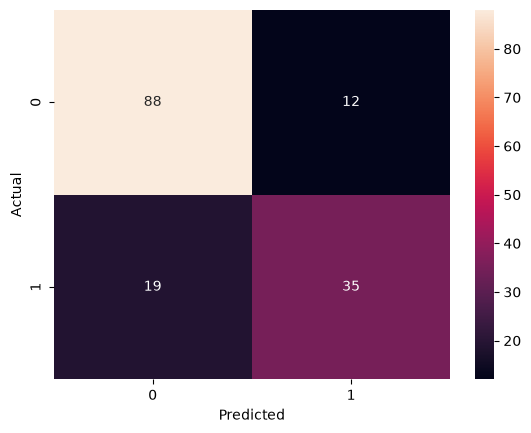

In [12]:
confusion_matrix=pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(confusion_matrix, annot=True)